In [35]:
import os
import pandas as pd
import glob
import json
import matplotlib.pyplot as plt
import numpy as np

# Define the common parent directory 
parent_dir = '../outputs/20250225_mid_iota/'
# Get all result directories under the parent directory
result_dirs = [d for d in glob.glob(os.path.join(parent_dir, '*')) if os.path.isdir(d)]

df = pd.DataFrame()
# Loop through directories and read results.json
for result_dir in result_dirs:
    result_file = os.path.join(result_dir, 'results.json')
    if not os.path.isfile(result_file):
        continue  # Skip if results.json does not exist
    try:
        with open(result_file, 'r') as f:
            data = json.load(f)
        # Extract the directory name relative to the parent directory
        relative_dirname = os.path.relpath(result_dir, parent_dir)
        # Add relative directory name to data
        data['dirname'] = relative_dirname
        # Normalize nested lists
        df = pd.concat([df, pd.json_normalize(data)], ignore_index=True)
    except (json.JSONDecodeError, ValueError) as e:
        print(f"Error reading {result_file}: {e}")
        continue

if df.empty: raise Exception("Dataframe is empty: check that the parent directory name is correct")

In [36]:
metric_key = {
    'wp_max_max_force': r'$\left|\bf{\frac{dF}{dL}}\right|_{max,dipoles}$ [N/m]',
    'avg_Bnormal': r'$\langle \bf{B} \cdot \hat{n} / \mid B \mid \rangle$',
    'max_Bnormal': r'$\max(\bf{B} \cdot \hat{n} / \mid B \mid)$',

}

In [37]:
# Print dataframe keys to check structure
best_result = df.loc[df['avg_Bnormal'].idxmin()]
# Print the best parameters
print("Lowest Average Bnormal Found:")
print(best_result)

Lowest Average Bnormal Found:
filament_distance                                              0.05
half_period_distance                                           0.05
inboard_radius                                                0.045
numquadpoints                                                    64
VV_a                                                       0.265527
                                           ...                     
avgR0                                                          None
maxtilt                                                        None
mintilt                                                        None
avgtilt                                                        None
dirname                 21_20250225_diprad_0.045_VV_plas_dist_0.130
Name: 6, Length: 70, dtype: object


In [38]:
df_temp = df.loc[df['ntf'] == 4]

In [42]:
VV_amin = 0.2055 - 0.07

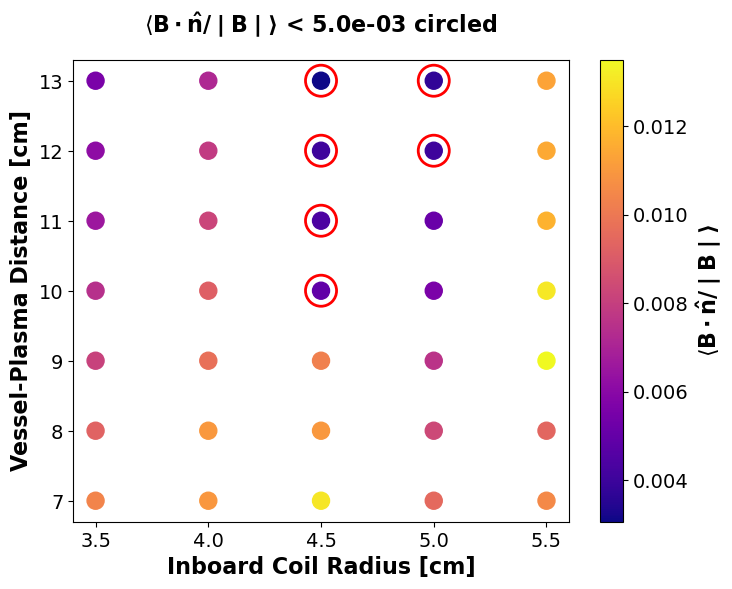

In [45]:
metric = 'avg_Bnormal'
fig = plt.figure(figsize=(8, 6))
ax = fig.add_subplot(111)
# Scatter plot with a different colormap
sc = ax.scatter(100*df_temp['inboard_radius'], 100*(df_temp['VV_a']-VV_amin), 
                c=df_temp[metric], s=150, cmap='plasma')
# Define the threshold value
threshold_value = 5e-3  # Adjust this value as needed

# Highlight the values less than the threshold with a red circle
highlight_idx = df_temp[df_temp[metric] < threshold_value].index
ax.scatter(100*df_temp.loc[highlight_idx, 'inboard_radius'], 100*(df_temp.loc[highlight_idx, 'VV_a']-VV_amin), 
           color=None, edgecolor='red', s=500, linewidth=2, facecolors='none')

# Labels and title
ax.set_xlabel('Inboard Coil Radius [cm]', fontweight='bold', fontsize=16)
ax.set_ylabel('Vessel-Plasma Distance [cm]', fontweight='bold', fontsize=16)
ax.tick_params(labelsize=14)

# Add title indicating the threshold
ax.set_title(f'{metric_key[metric] if metric in metric_key.keys() else metric} < {threshold_value:.1e} circled', fontweight='bold', fontsize=16, pad=20)
# Add colorbar
cbar = fig.colorbar(sc, ax=ax)
cbar.ax.tick_params(labelsize=14)
cbar.ax.set_ylabel(f'{metric_key[metric] if metric in metric_key.keys() else metric}', fontsize=16, fontweight='bold')

plt.show()
# # Create a contour plot
# contour = ax.tricontourf(100*df_temp['inboard_radius'], 100*(df_temp['VV_a']-0.17), df_temp[metric], cmap='plasma')
# ax.set_xlabel('Inboard Coil Radius [cm]', fontweight='bold', fontsize=16)
# ax.set_ylabel('Vessel-Plasma Distance [cm]', fontweight='bold', fontsize=16)
# ax.tick_params(labelsize=14)
# cbar = fig.colorbar(contour, ax=ax)
# cbar.ax.tick_params(labelsize=14)
# cbar.ax.set_ylabel(f'{metric}', fontsize=16, fontweight='bold')

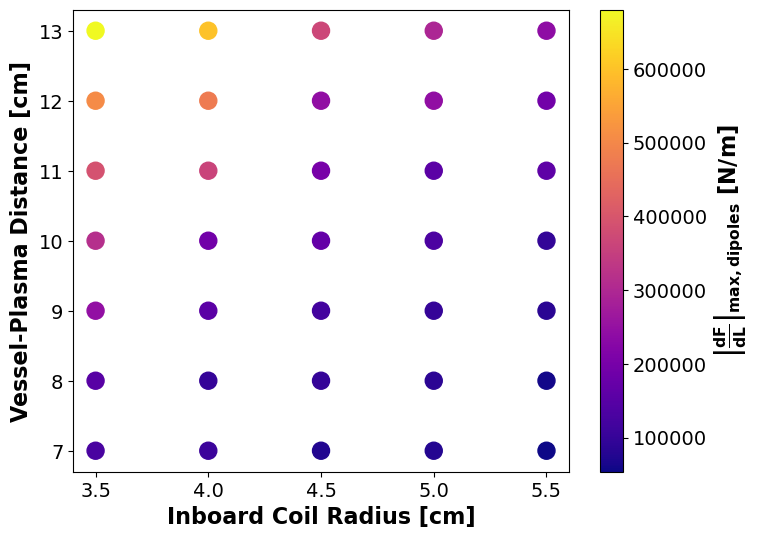

In [44]:
metric = 'wp_max_max_force'
fig = plt.figure(figsize=(8, 6))
ax = fig.add_subplot(111)
# Scatter plot with a different colormap
sc = ax.scatter(100*df_temp['inboard_radius'], 100*(df_temp['VV_a']-VV_amin), 
                c=df_temp[metric], s=150, cmap='plasma')
# Define the threshold value
threshold_value = 0  # Adjust this value as needed

# Highlight the values less than the threshold with a red circle
highlight_idx = df_temp[df_temp[metric] < threshold_value].index
ax.scatter(100*df_temp.loc[highlight_idx, 'inboard_radius'], 100*(df_temp.loc[highlight_idx, 'VV_a']-VV_amin), 
           color=None, edgecolor='red', s=500, linewidth=2, facecolors='none')

# Labels and title
ax.set_xlabel('Inboard Coil Radius [cm]', fontweight='bold', fontsize=16)
ax.set_ylabel('Vessel-Plasma Distance [cm]', fontweight='bold', fontsize=16)
ax.tick_params(labelsize=14)

# Add title indicating the threshold
#ax.set_title(f'{metric} < {threshold_value:} circled', fontweight='bold', fontsize=16, pad=20)
# Add colorbar
cbar = fig.colorbar(sc, ax=ax)
cbar.ax.tick_params(labelsize=14)
cbar.ax.set_ylabel(f'{metric_key[metric] if metric in metric_key.keys() else metric}', fontsize=16, fontweight='bold')

plt.show()